### **Prerequisites**

In the previous notebook, we learned how to:

- Create the feature matrix (`X`) and target variable (`y`)
- Encode categorical features
- Scale numerical features
- Split the dataset into training and testing sets

In this notebook, we will apply these concepts to build our first **Machine Learning model using Linear Regression**.

We will recreate the required variables so that this notebook can be executed independently.

#### **Import Required Libraries**

We will use several Python libraries and tools to build the Machine Learning workflow.

- `pandas` → load and work with tabular data
- `train_test_split` → divide data into training and testing sets
- `ColumnTransformer` → apply different preprocessing methods to different columns
- `OneHotEncoder` → convert categorical data into numerical form
- `StandardScaler` → scale numerical features
- `Pipeline` → combine preprocessing and the Machine Learning model
- `LinearRegression` → build the regression model
- `Regression metrics` → evaluate the model's predictive performance
- `joblib` → save and load the trained model

In [21]:
# Import Required Libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [22]:
# Load the cleaned dataset
df = pd.read_csv("../datasets/cleaned/student_performance_cleaned.csv")

#### **1. Define the Target Variable**

In this notebook, the target variable is **`marks`**.

Because `marks` is a continuous numerical target, this is a **regression problem**.

The model will learn to predict a student's marks from the selected input features.

In [23]:
# Define the Target Variable

y = df["marks"]

##### **1.1 Select Input Features**

In [24]:
# Select Input Features

feature_columns = [
    "age",
    "semester",
    "attendance_percentage",
    "tuition_fee",
    "department",
    "gender",
    "scholarship"
]

X = df[feature_columns].copy()

#### **2. Identify Numerical and Categorical Features**

Machine Learning datasets often contain different types of input features.

- **Numerical features** contain numerical values and may require scaling.
- **Categorical features** contain categories and must be converted into numerical representations.

We will handle these two groups separately using a `ColumnTransformer`.

In [25]:
# Define Numerical Features

numerical_features = [
    "age",
    "semester",
    "attendance_percentage",
    "tuition_fee"
]

# Define Categorical Features

categorical_features = [
    "department",
    "gender",
    "scholarship"
]

#### **3. Train-Test Split**

Before training the Machine Learning model, we divide our dataset into two parts:

- **Training data** → used to teach the model
- **Testing data** → used to check how well the model performs on unseen data

We will use **80% of the data for training** and **20% for testing**.

The testing data is kept separate during training so that we can evaluate the model fairly after it has learned from the training data.

In [26]:
# Split the Dataset into Training and Testing Sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [27]:
# Display Dataset Shapes

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (116, 7)
X_test : (29, 7)
y_train: (116,)
y_test : (29,)


##### **Why Do We Split Before Preprocessing?**

We split the data into training and testing sets **before** applying preprocessing.

Some preprocessing methods learn information from the data.

For example:

- `StandardScaler` learns values such as the mean and standard deviation.
- `OneHotEncoder` learns the categories found in the data.

These values should be learned from the **training data only**.

The testing data must remain separate until we evaluate the final model.

This prevents **data leakage**, which means accidentally allowing information from the testing data to influence the training process.

#### **4. Build the Preprocessing Pipeline**

Our dataset contains two types of input features:

- **Numerical features** → `age`, `semester`, `attendance_percentage`, and `tuition_fee`
- **Categorical features** → `department`, `gender`, and `scholarship`

These two types of features require different preprocessing methods.

We will use:

- **StandardScaler** for numerical features
- **OneHotEncoder** for categorical features

A `ColumnTransformer` allows us to apply the appropriate preprocessing method to each group of columns.

This keeps the preprocessing organized and allows us to use the same preprocessing steps consistently during model training and prediction.

```text
                 Input X
                    ↓
           ColumnTransformer
              /          \
             /            \
      Numerical          Categorical
         ↓                   ↓
 StandardScaler        OneHotEncoder
         ↓                   ↓
         └─────────┬─────────┘
                   ↓
           Processed X
```

In [28]:
# Create the Preprocessing Transformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore",sparse_output=False),categorical_features)
    ]
)

##### **Why Use StandardScaler?**

Linear Regression does not strictly require feature scaling.

However, our numerical features have different ranges. For example, `age`, `attendance_percentage`, and `tuition_fee` can have very different numerical values.

Using `StandardScaler` puts the numerical features on a more comparable scale.

In this notebook, `StandardScaler` is used as part of the preprocessing workflow.

The scaler will be fitted only on the training data when we train the Machine Learning Pipeline.

#### **5. Build the Linear Regression Pipeline**

A Machine Learning **Pipeline** connects multiple steps into one workflow.

In our case, the Pipeline contains two main steps:

1. **Preprocessing**
   - StandardScaler for numerical features
   - OneHotEncoder for categorical features

2. **Linear Regression**
   - The model learns from the processed features

The order is:

**Raw Features → Preprocessing → Linear Regression**

Using a Pipeline keeps these steps together and ensures that the same preprocessing workflow is used consistently during training and prediction.

In [29]:
# Create the Machine Learning Pipeline

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

#### **6. Train the Linear Regression Model**

We now train the complete Machine Learning Pipeline using the training data.

The `fit()` method tells the Pipeline to learn from:

- `X_train` → input features
- `y_train` → actual target values (`marks`)

During training, the Pipeline:

1. Preprocesses the numerical features using `StandardScaler`.
2. Encodes the categorical features using `OneHotEncoder`.
3. Trains the Linear Regression model using the processed training data.

The preprocessing steps learn their parameters from the **training data only**.

In [30]:
# Train the Model

model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['age','semester','attendance_percentage',...,'department','gender', 'scholarship']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This sub

#### **7. Make Predictions**

The model has now been trained using the training data.

We can now use the **testing features (`X_test`)** to ask the trained model to predict the marks of the test students.

The Pipeline automatically:

1. Applies the preprocessing learned from the training data.
2. Sends the processed test features to the trained Linear Regression model.
3. Returns the predicted marks.

The testing target (`y_test`) is **not given to the model during prediction**. We keep it separate so that we can compare the predictions with the actual marks later.

In [31]:
# Generate Predictions

y_pred = model.predict(X_test)

#### **8. Evaluate the Model**

##### **8.1 Understanding Regression Evaluation Metrics**

After making predictions, we need to determine how well our model performed.

We use four common regression metrics:

**MAE — Mean Absolute Error**

> On average, how many units is the model's prediction away from the actual value?

Lower MAE is better.

**MSE — Mean Squared Error**

> What is the average squared prediction error?

Because errors are squared, large errors receive more weight.

Lower MSE is better.

**RMSE — Root Mean Squared Error**

> What is the prediction error in the same unit as the target, while giving more importance to large errors?

Lower RMSE is better.

**R² — R-Squared**

> How much of the variation in the target variable is explained by the model?

Higher R² is generally better, with 1 representing perfect explanatory performance.

In [32]:
# Calculate Regression Metrics

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

MAE : 4.51
MSE : 30.16
RMSE: 5.49
R²  : 0.24


##### **8.2 Initial Model Interpretation**

The Linear Regression model provides a baseline for predicting student marks.

The model achieved:

- **MAE = 4.51**
- **MSE = 30.16**
- **RMSE = 5.49**
- **R² = 0.24**

##### **Interpretation**

- **MAE = 4.51** means that the model's predictions differ from the actual marks by approximately **4.51 marks on average**.
- **RMSE = 5.49** indicates that the typical prediction error is approximately **5.49 marks**, while giving more weight to larger errors.
- **R² = 0.24** indicates that the selected features and Linear Regression model explain approximately **24% of the variation in student marks** on the test set.

These results represent the **baseline performance** of the Linear Regression model. They should not be considered the final model performance.

Later, we can compare this baseline with other Machine Learning models and determine whether a different model or additional feature engineering improves the results.

#### **9. Actual vs Predicted Values**

After evaluating the model using regression metrics, we can inspect individual predictions.

This table compares:

- **Actual Marks** → the real marks from the test dataset (`y_test`)
- **Predicted Marks** → the marks predicted by the trained model (`y_pred`)
- **Absolute Error** → the absolute difference between actual and predicted marks

This allows us to see how close the model's predictions are for individual students.

In [33]:
# Create Actual vs Predicted Comparison

results = pd.DataFrame({
    "Actual Marks": y_test,
    "Predicted Marks": y_pred
})

# Calculate Absolute Prediction Error

results["Absolute Error"] = (
    results["Actual Marks"] - results["Predicted Marks"]
).abs()

results.head(10)

,Actual Marks,Predicted Marks,Absolute Error
69,73.0,72.876083,0.123917
140,82.0,82.584599,0.584599
27,86.0,80.621878,5.378122
19,79.0,78.559416,0.440584
42,90.0,85.134487,4.865513
117,94.0,86.705762,7.294238
126,74.0,72.055959,1.944041
108,78.0,81.803899,3.803899
84,88.0,85.237808,2.762192
18,78.0,85.900543,7.900543


#### **10. Actual vs Predicted Visualization**

A scatter plot helps us visually compare the actual marks with the marks predicted by the model.

- **X-axis** → Actual Marks
- **Y-axis** → Predicted Marks

The diagonal reference line represents **perfect predictions**, where the predicted value is equal to the actual value.

If the points are close to the diagonal line, the predictions are close to the actual values.

Points above the line indicate over-prediction, while points below the line indicate under-prediction.

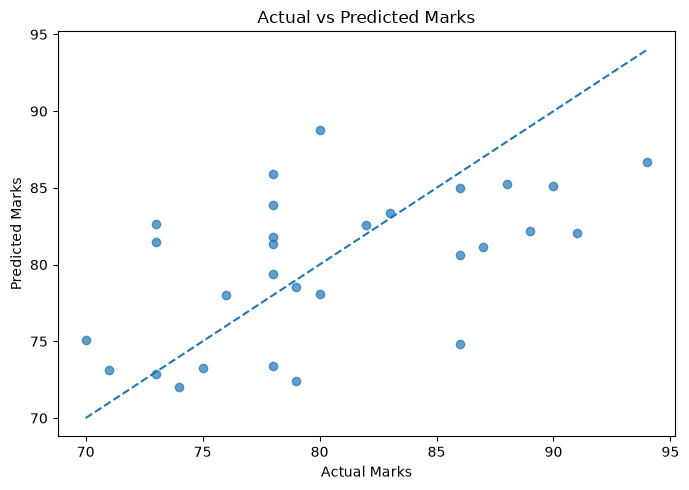

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")

plt.tight_layout()
plt.show()

#### **11. Save the Complete Machine Learning Pipeline**

After training and evaluating the model, we can save the complete Machine Learning Pipeline for future use.

The saved Pipeline contains:

- The preprocessing steps
  - `StandardScaler`
  - `OneHotEncoder`
- The trained `LinearRegression` model

Saving the complete Pipeline is important because future data must go through the **same preprocessing steps** that were learned during training.

This allows us to load the trained Pipeline later and make predictions without retraining the model.

In [35]:
# Save the Complete Pipeline

joblib.dump(
    model,
    "../models/linear_regression_model.pkl"
)

['../models/linear_regression_model.pkl']

#### **12. Load the Saved Machine Learning Pipeline**

The trained Pipeline was saved to a `.pkl` file.

We can load this saved Pipeline later and use it to make predictions without retraining the model.

Because the preprocessing steps are included inside the Pipeline, new data automatically goes through the same preprocessing workflow that was learned during training.

In [36]:
# Load the Saved Pipeline

loaded_model = joblib.load(
    "../models/linear_regression_model.pkl"
)

In [37]:
# Generate Predictions Using the Loaded Pipeline

loaded_predictions = loaded_model.predict(X_test)

loaded_predictions[:5]

array([72.87608287, 82.58459949, 80.62187822, 78.55941572, 85.13448651])

In [38]:
# Verify That the Loaded Model Produces the Same Predictions

comparison = pd.DataFrame({
    "Original Prediction": y_pred[:5],
    "Loaded Model Prediction": loaded_predictions[:5]
})

comparison

,Original Prediction,Loaded Model Prediction
0,72.876083,72.876083
1,82.584599,82.584599
2,80.621878,80.621878
3,78.559416,78.559416
4,85.134487,85.134487


In [39]:
# Verify All Predictions Match

np.allclose(
    y_pred,
    loaded_predictions
)

True